In [ ]:
from ihp import PDK
from ihp.cells.capacitors import cmom
from gsim.palace import DrivenSim
from pathlib import Path

PDK.activate()
yaml_file = Path("~/projects/IHP/ihp/s_parameters/ihp_stack.yaml").expanduser()

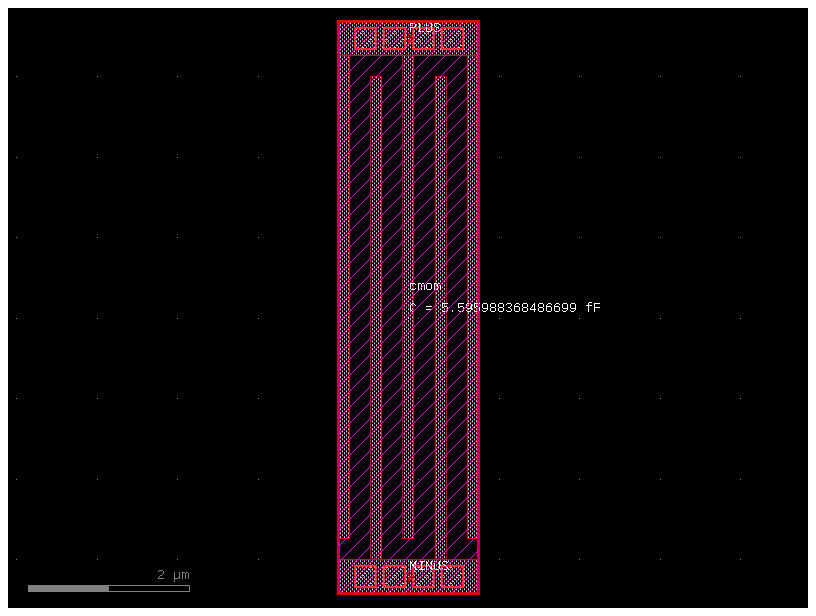

In [36]:
c = cmom(nfingers=2, length=6.0)

#We exclude nofill layers
keep_layers = [
    (8, 0),    # Metal1drawing
    (10, 0),   # Metal2drawing
    (30, 0),   # Metal3drawing
    (30, 2),   # Metal3pin
    #(19, 0),   # Via1drawing
    #(29, 0),   # Via2drawing
    (69, 0),   # MemCapdrawing
]

cc = c.extract(layers=keep_layers)
cc.add_ports(c.ports)

c.draw_ports()

c.plot()

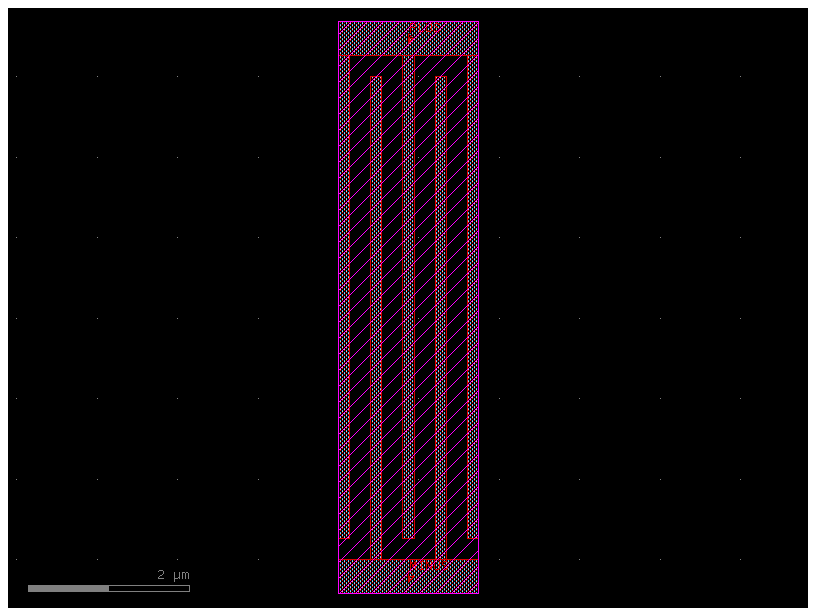

In [37]:
cc.plot()

We remove the Via1drawing and Via2drawing layers, since otherwise mesh generation produces the following error:
```
Error   : PLC Error:  A segment and a facet intersect at point
---------------------------------------------------------------------------
Exception                                 Traceback (most recent call last)
/tmp/ipykernel_595466/660362261.py in ?()
      1 # TODO: investigate why Z dimension is much larger than expected.
      2 # The full IHP stack inflates the domain, air_above and layer filtering don't seem to help —
      3 # likely get_stack() pre-computes a fixed zmax/bbox independent of stack.layers.
      4 
----> 5 sim.mesh(preset="graded",margin=0.5, refined_mesh_size=0.2)

~/projects/gsim/src/gsim/palace/driven.py in ?(self, preset, refined_mesh_size, max_mesh_size, margin, airbox_margin, fmax, planar_conductors, show_gui, model_name, verbose)
    662         # Extract ports
    663         palace_ports = extract_ports(component, stack)
    664 
    665         # Generate mesh (config is written separately by simulate() or write_config())
--> 666         return self._generate_mesh_internal(
    667             output_dir=output_dir,
    668             mesh_config=mesh_config,
    669             ports=palace_ports,

~/projects/gsim/src/gsim/palace/driven.py in ?(self, output_dir, mesh_config, ports, driven_config, model_name, verbose, write_config)
    461 
    462         if verbose:
    463             logger.info("Generating mesh in %s", output_dir)
    464 
--> 465         mesh_result = generate_mesh(
    466             component=component,
    467             stack=stack,
    468             ports=ports,

~/projects/gsim/src/gsim/palace/mesh/pipeline.py in ?(component, stack, ports, output_dir, config, model_name, driven_config, write_config, pec_blocks)
    205 
    206     output_dir = Path(output_dir)
    207 
    208     # Use new generator
--> 209     result = gen_mesh(
    210         component=component,
    211         stack=stack,
    212         ports=ports,

~/projects/gsim/src/gsim/palace/mesh/generator.py in ?(component, stack, ports, output_dir, model_name, refined_mesh_size, max_mesh_size, margin, air_margin, fmax, show_gui, driven_config, write_config, planar_conductors, refine_from_curves, pec_blocks, merge_via_distance)
    293             )
    294 
    295     finally:
    296         gmsh.clear()
--> 297         gmsh.finalize()
    298 
    299     # Build result (store groups for deferred config generation)
    300     result = MeshResult(

~/projects/gsim/.venv/lib/python3.12/site-packages/gmsh.py in ?(dim)
   2185             lib.gmshModelMeshGenerate(
   2186                 c_int(dim),
   2187                 byref(ierr))
   2188             if ierr.value != 0:
-> 2189                 raise Exception(logger.getLastError())

Exception: PLC Error:  A segment and a facet intersect at point
```

In [38]:
# Checking the port layers.
cc.ports

["Port(self.name='PLUS', self.width=140, trans=r0 *1 0.87,6.47, layer=Metal3pin (30/2), port_type=electrical)", "Port(self.name='MINUS', self.width=140, trans=r0 *1 0.87,-0.21, layer=Metal3pin (30/2), port_type=electrical)"]

In [39]:
sim = DrivenSim()
sim.set_output_dir("runs/palace-sim-cmom")
sim.set_geometry(cc)

sim.set_stack(substrate_thickness=1.0, air_above=0.5)

sim.add_port("PLUS",from_layer="metal1",to_layer="metal3", geometry="via",excited=True)
sim.add_port("MINUS",from_layer="metal1",to_layer="metal3",geometry="via",excited=False)

sim.set_driven(fmin=1e9, fmax=100e9, num_points=60)

print(sim.validate_config())

Validation: PASSED


In [ ]:
#TODO: investigate why XY dimension is much larger than expected.
sim.mesh(preset="graded", refined_mesh_size=0.2)

Mesh Summary
Dimensions: 101.7 x 107.1 x 17.8 µm
Nodes:      5,581
Elements:   44,227
Tetrahedra: 32,613
Edge length: 0.09 - 56.16 µm
Quality:    0.623 (min: 0.001)
SICN:       0.661 (all valid)
----------------------------------------
Volumes (3):
  - SiO2 [1]
  - passive [2]
  - air [3]
Surfaces (13):
  - metal1_xy [4]
  - metal1_z [5]
  - metal2_xy [6]
  - metal2_z [7]
  - metal3_xy [8]
  - metal3_z [9]
  - P1 [10]
  - P2 [11]
  - SiO2__None [12]
  - SiO2__passive [13]
  - passive__None [14]
  - air__passive [15]
  - air__None [16]
----------------------------------------
Mesh:   runs/palace-sim-cmom/palace.msh

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

2026-04-01 01:43:21.420 (7814.877s) [    76FBB9A1F080]vtkEGLRenderWindowInter:218   WARN| EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

2026-04-01 01:43:21.430 (7814.887s) [    76FBB9A1F080]vtkEGLRenderWindowInter:218   WARN| EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

2026-04-01 01:43:21.473 (7814.930s) [    76FBB9A1F080]vtkEGLRenderWindowInter:218   WARN| EGL device index: 0 could not be initialized. Trying other devices...


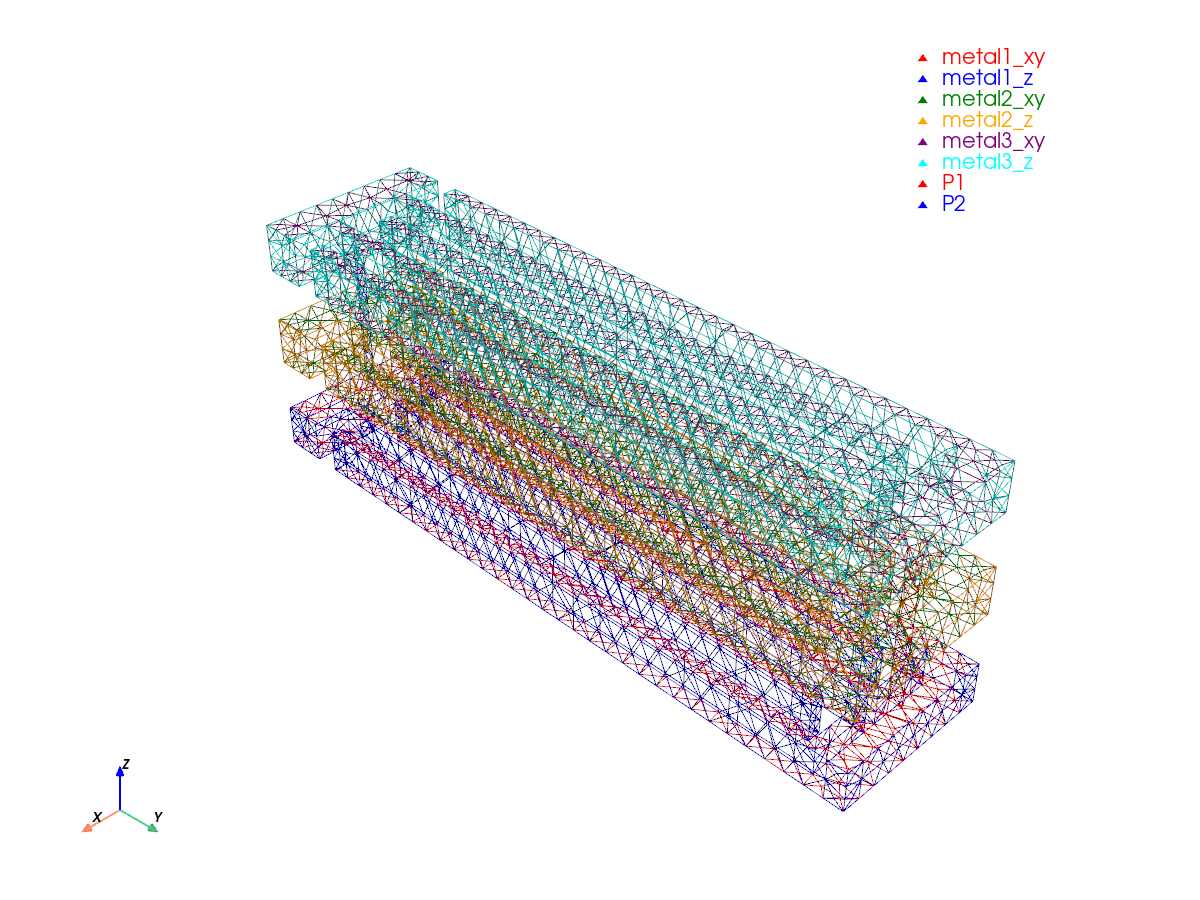

In [41]:
sim.plot_mesh(show_groups=["metal","P"], interactive=False)

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

2026-04-01 01:43:21.648 (7815.104s) [    76FBB9A1F080]vtkEGLRenderWindowInter:218   WARN| EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

2026-04-01 01:43:21.657 (7815.114s) [    76FBB9A1F080]vtkEGLRenderWindowInter:218   WARN| EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

2026-04-01 01:43:21.688 (7815.145s) [    76FBB9A1F080]vtkEGLRenderWindowInter:218   WARN| EGL device index: 0 could not be initialized. Trying other devices...


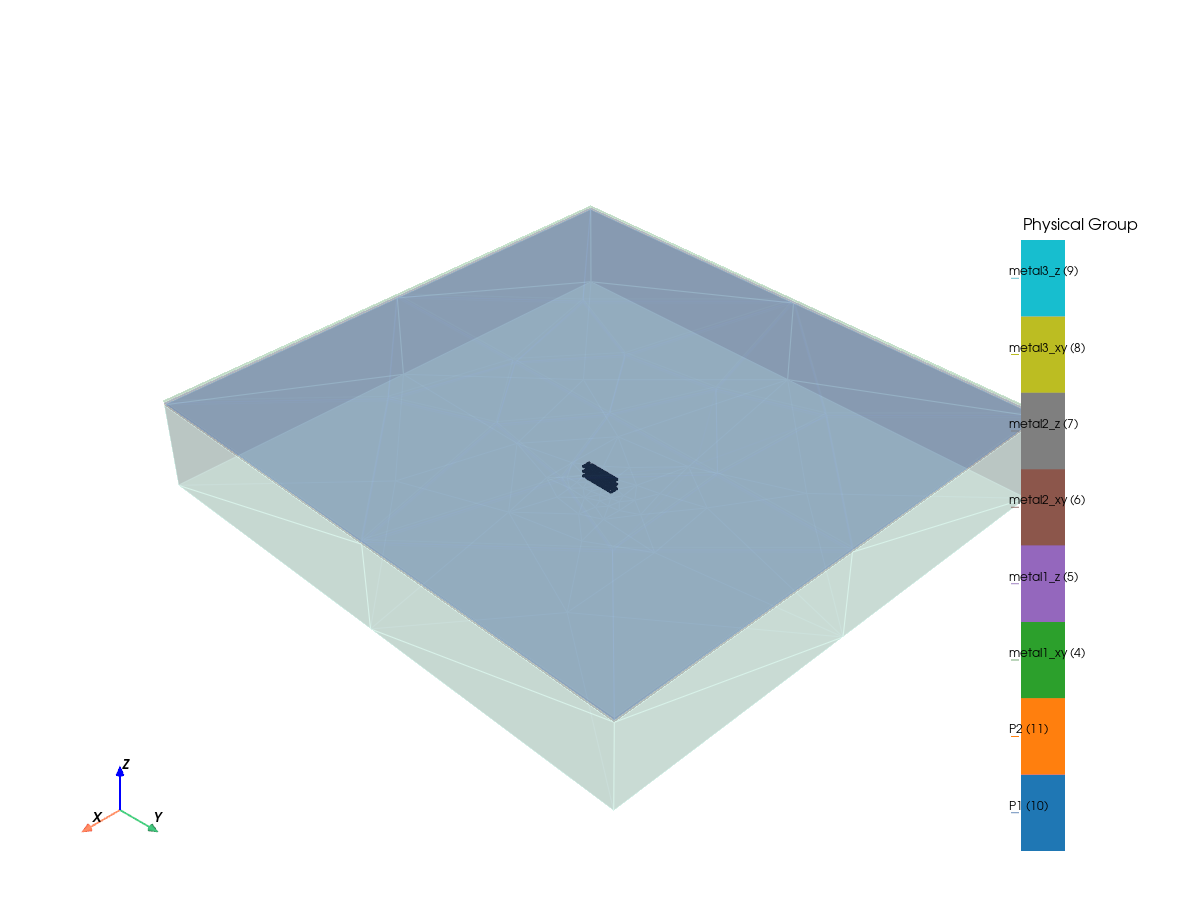

In [42]:
sim.plot_mesh(
    style="solid", interactive=False, 
    transparent_groups=["passive__None","air__None","air__passive","SiO2__None","SiO2__passive"],
)

In [43]:
results = sim.run(parent_dir="runs")

  palace-efddbd2c  completed  0m 52s
Extracting results.tar.gz...
Downloaded 11 files to runs/sim-data-palace-efddbd2c


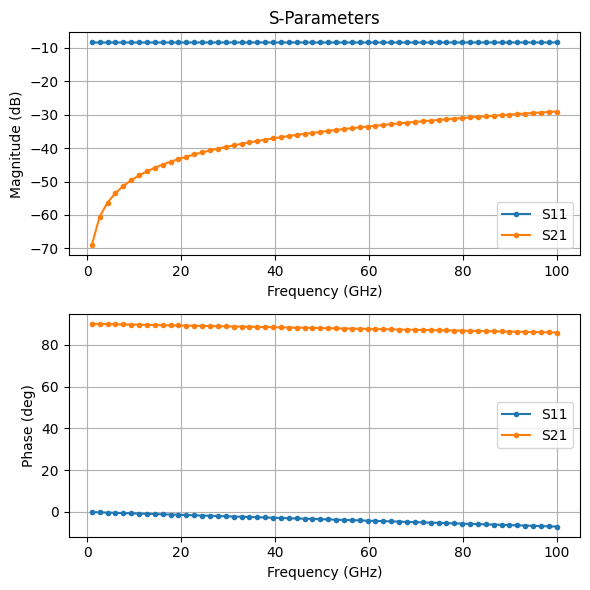

In [44]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv(results["port-S.csv"])
df.columns = df.columns.str.strip()  # Remove whitespace from column names

freq = df["f (GHz)"]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 6))

# Magnitude plot
ax1.plot(freq, df["|S[1][1]| (dB)"], marker=".", label="S11")
ax1.plot(freq, df["|S[2][1]| (dB)"], marker=".", label="S21")
ax1.set_xlabel("Frequency (GHz)")
ax1.set_ylabel("Magnitude (dB)")
ax1.set_title("S-Parameters")
ax1.legend()
ax1.grid(True)

# Phase plot
ax2.plot(freq, df["arg(S[1][1]) (deg.)"], marker=".", label="S11")
ax2.plot(freq, df["arg(S[2][1]) (deg.)"], marker=".", label="S21")
ax2.set_xlabel("Frequency (GHz)")
ax2.set_ylabel("Phase (deg)")
ax2.legend()
ax2.grid(True)

plt.tight_layout()